In [94]:
import pandas as pd

In [95]:
df= pd.read_csv(r"C:\Users\Brian Singogo\OneDrive\Documents\titanidatabase\train.csv")

In [96]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [98]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [99]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [100]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [101]:
df = df.drop(columns=["Cabin"])

In [102]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [103]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [104]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [105]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [106]:
df["Survived"].mean()

0.3838383838383838

In [107]:
df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [108]:
df.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [109]:
df.groupby("Age")["Survived"].mean()

Age
0.42     1.0
0.67     1.0
0.75     1.0
0.83     1.0
0.92     1.0
        ... 
70.00    0.0
70.50    0.0
71.00    0.0
74.00    0.0
80.00    1.0
Name: Survived, Length: 88, dtype: float64

In [110]:
import matplotlib.pyplot as plt

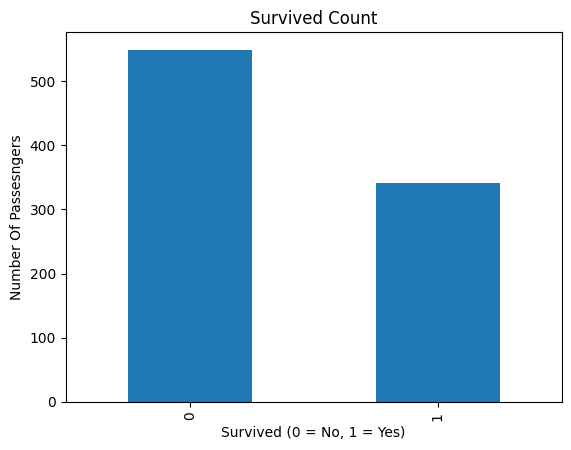

In [111]:
df["Survived"].value_counts().plot(kind="bar")
plt.title("Survived Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number Of Passesngers")
plt.show()

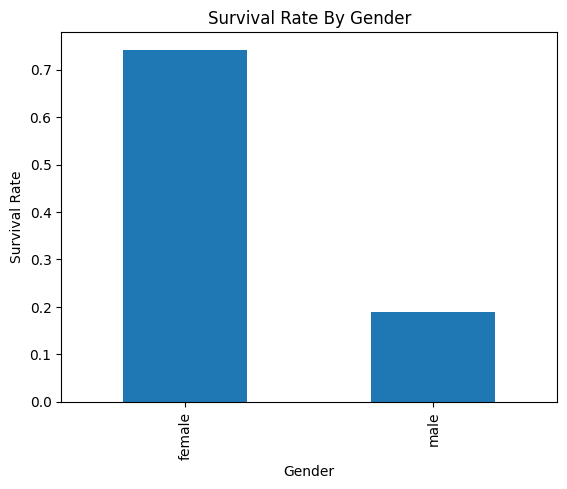

In [112]:
df.groupby("Sex")["Survived"].mean().plot(kind="bar")
plt.title("Survival Rate By Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.show()

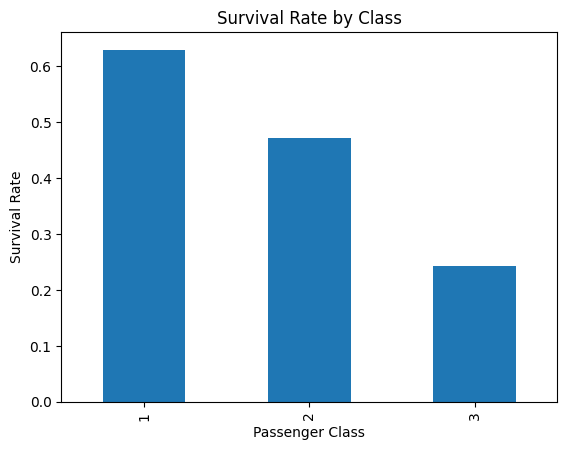

In [113]:
df.groupby("Pclass")["Survived"].mean().plot(kind="bar")
plt.title("Survival Rate by Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

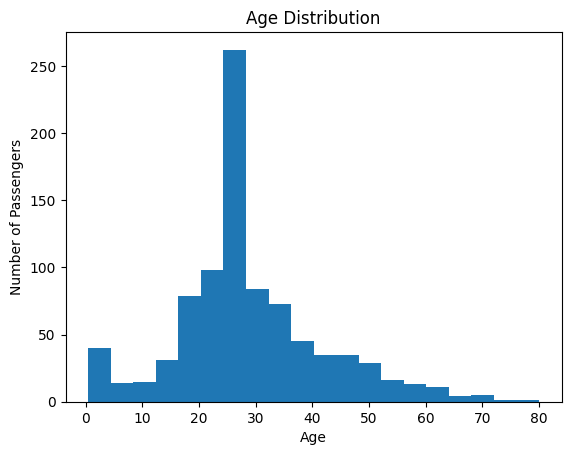

In [114]:
df["Age"].plot(kind="hist", bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

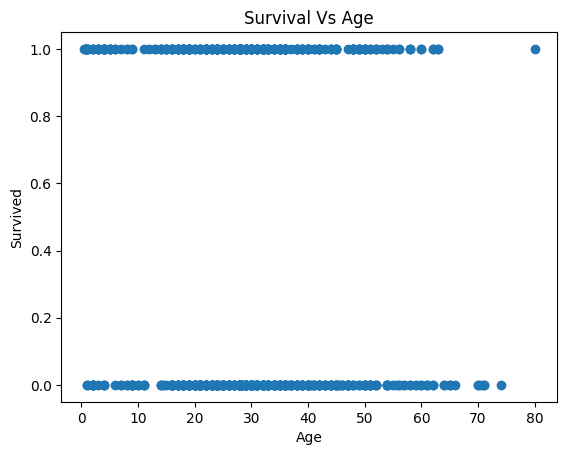

In [115]:
plt.scatter(df["Age"], df["Survived"])
plt.title("Survival Vs Age")
plt.xlabel("Age")
plt.ylabel("Survived")
plt.show()

In [116]:
df.groupby(pd.cut(df["Age"], bins=[0, 12, 18, 35, 60, 100]))["Survived"].mean()

Age
(0, 12]      0.579710
(12, 18]     0.428571
(18, 35]     0.353271
(35, 60]     0.400000
(60, 100]    0.227273
Name: Survived, dtype: float64

In [117]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [118]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [119]:
df.groupby("FamilySize")["Survived"].mean()

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

In [120]:
def Family_Category(size):
    if size == 1:
        return "Alone"
    elif size <= 4:
        return "Small"
    else:
        return "Large"
df["FamilyCategory"] = df["FamilySize"].apply(Family_Category)

In [121]:
df.groupby("FamilyCategory")["Survived"].mean()

FamilyCategory
Alone    0.303538
Large    0.161290
Small    0.578767
Name: Survived, dtype: float64

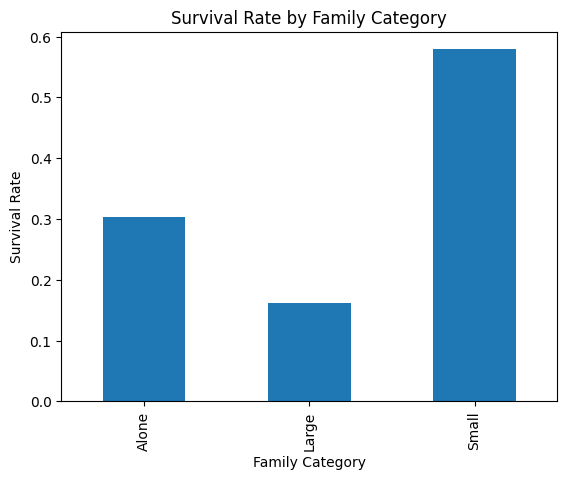

In [122]:
df.groupby("FamilyCategory")["Survived"].mean().plot(kind="bar")
plt.title("Survival Rate by Family Category")
plt.xlabel("Family Category")
plt.ylabel("Survival Rate")
plt.show()

In [123]:
df["AgeGroup"] = pd.cut(df["Age"], bins=[0, 12, 18, 35, 60, 100], labels=["Child", "Teen", "Adult", "Middle Age", "Senior"])

<Axes: xlabel='AgeGroup'>

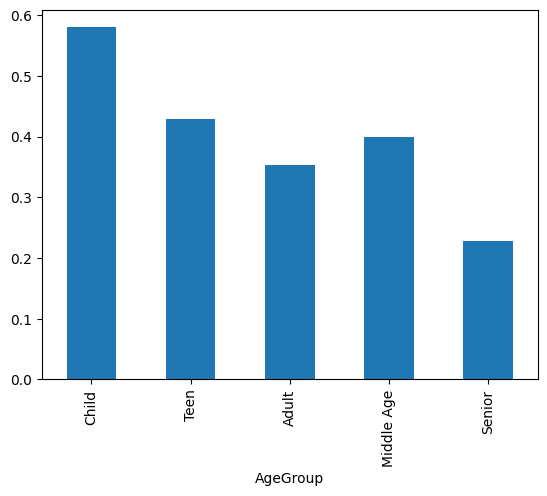

In [124]:
df.groupby("AgeGroup")["Survived"].mean().plot(kind="bar")